# TMT data normalization

## Study Background
In this tutorial, we showcase how alphapepttools can be used to work with _Tandem Mass Tag_ (TMT) data, a common multiplexing approach in MS-based proteomics.

In multiplexing approaches, peptides from several samples are analyzed simultaneously in a single mass spectrometry run. The samples are distinguished by covalently labeling their peptides with isobaric chemical "mass tags". These tags are chemically equivalent (i.e. they co-elute in the LC run) and have the same total mass, therefore labeled versions of the same peptide appear at the same `m/z` ratio in the MS1 scan. The tags differ, however, in how their heavy isotopes are distributed across the molecule. Upon fragmentation, each tag releases a reporter ion of a distinct mass, which produces a set of resolvable peaks in the MS2 (or sometimes MS3) scan. The relative intensities of these reporter ions encode the abundance of the peptide from each of the multiplexed samples.

Mass-tag multiplexing increases throughput, since multiple samples are measured in a single run, and improves comparability between samples of the same run ("plex"). Making samples comparable across plexes, however, requires careful normalization.

As reviewed in [Huang et al, 2020](https://doi.org/10.1074/mcp.RA120.002105), the analysis of TMT data can be split into three steps, with 1. and 2. often being performed internally by the search engine:

1. Spectrum-level normalization
2. Protein summarization
3. Protein-level normalization

The aggregated protein intensities have to be made comparable both within and between plexes.

Several approaches exist to normalize TMT data (as reviewed in [Huang et al, 2020](https://doi.org/10.1074/mcp.RA120.002105)). A common one is _internal reference standardization_ (IRS), which aligns plexes against a common reference sample that was measured in every plex ([Plubell et al, 2017](https://doi.org/10.1074/mcp.m116.065524)). 

We follow the tutorial by [Phil Wilmarth](https://pwilmart.github.io/IRS_normalization/understanding_IRS.html) and process a TMT dataset of developing mouse lenses using IRS normalization.

## References

> Huang, Ting, Meena Choi, Manuel Tzouros, et al. “MSstatsTMT: Statistical Detection of Differentially Abundant Proteins in Experiments with Isobaric Labeling and Multiple Mixtures.” _Molecular & Cellular Proteomics_ 19, no. 10 (2020): 1706–23. [https://doi.org/10.1074/mcp.RA120.002105](https://doi.org/10.1074/mcp.RA120.002105).

> Plubell, D. L. et al. Extended Multiplexing of Tandem Mass Tags (TMT) Labeling Reveals Age and High Fat Diet Specific Proteome Changes in Mouse Epididymal Adipose Tissue. Mol Cell Proteomics 16, 873–890 (2017). https://doi.org/10.1074/mcp.m116.065524

> Phil Wilmarth, 2018: https://pwilmart.github.io/IRS_normalization/understanding_IRS.html (MIT License)

## Analysis

We import alphapepttools together with a few packages for data wrangling and visualization, and define a helper function to plot the intensity distributions of the samples.

In [ ]:
import alphapepttools as apt
import anndata as ad
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

/Users/lucas-diedrich/mamba/envs/alphatools/lib/python3.12/site-packages/mudata/__init__.py:30: DeprecationWarning: The decorator_name argument is deprecated and will be removed in the future.
  register_mudata_namespace = _make_register_namespace_decorator(MuData, "mdata", "register_mudata_namespace", "numpy")
/Users/lucas-diedrich/mamba/envs/alphatools/lib/python3.12/site-packages/mudata/__init__.py:30: DeprecationWarning: The docstring_style argument is deprecated and will be removed in the future.
  register_mudata_namespace = _make_register_namespace_decorator(MuData, "mdata", "register_mudata_namespace", "numpy")


In [ ]:
def plot_distribution(
    adata: ad.AnnData,
    layer: str | None = None,
    title: str = "",
) -> tuple:
    """Plot feature distributions of samples for Khan 2018 - TMT dataset

    References
    ----------
    - https://pwilmart.github.io/IRS_normalization/understanding_IRS.html
    """
    # Reshape the data to long format for plotting in boxplots/stripplots
    long_df = (
        adata.to_df(layer=layer).merge(adata.obs, left_index=True, right_index=True).melt(id_vars=adata.obs.columns)
    )

    # Generate a multi-panel figure in alphapepttools style
    fig, axm = apt.pl.create_figure(1, 2, figsize=(15, 5), gridspec_kwargs={"width_ratios": [3, 1]})

    # basic boxplot
    display(long_df.head())
    apt.pl.boxplot(
        ax=axm[0],
        data=long_df,
        grouping_column="sample",
        value_column="value",
        color=apt.pl.BaseColors.get("grey"),
    )

    # alphapepttools has no stripplot, use seaborn's implementation on same axis
    sns.stripplot(
        long_df,
        x="sample",
        y="value",
        ax=axm[0],
        size=0.2,
        color=apt.pl.BaseColors.get("black"),
    )

    # set x and y-axis labels
    apt.pl.label_axes(
        ax=axm[0],
        xlabel="Sample",
        ylabel="Reporter ion intensities",
        title="log2 intensities",
    )

    # In this case, cleaning up x-labels is beneficial for readability: remove repetitive "Reporter ion intensities" part
    axm[0].set_xticklabels([s.get_text().replace("Reporter ion intensities ", "") for s in axm[0].get_xticklabels()])
    axm[0].set_xticklabels(axm[0].get_xticklabels(), rotation=45, ha="right")

    # KDE plot with custom colors:
    color_dict = {
        "1": apt.pl.BaseColors.get("red"),
        "2": apt.pl.BaseColors.get("green"),
        "3": apt.pl.BaseColors.get("blue"),
    }
    sample_color_mapping = {s: color_dict[p] for s, p in adata.obs["plex"].items()}
    sns.kdeplot(long_df, x="value", hue="sample", legend=False, palette=sample_color_mapping, ax=axm[1])

    # Add a legend to the second plot
    apt.pl.add_legend_to_axes(
        ax=axm[1],
        levels=color_dict,
    )

    # set x and y-axis labels
    apt.pl.label_axes(
        ax=axm[1],
        xlabel="Reporter ion intensities",
        ylabel="Density",
        title="Density plot of log2 intensities",
    )

    # suptitle
    plt.suptitle(title)

    # show plot
    plt.show()

    return fig, axm

### 1. Data loading

We load the AnnData object with the raw search engine outputs from the data module. The original dataset consists of 3 TMT-plexes with 6 samples each. The samples are proteomics measurements of a time-course experiment in which mouse lenses were sampled at different developmental stages (15 and 18 days after conception; birth; and 3, 6, and 9 days after birth). This design provides a clear biological ground truth (we expect samples to order along developmental time) together with a clear batch structure (the three plexes).

In [ ]:
path = apt.data.get_data("khan2018")
adata = ad.read_h5ad(path)

  utils.warn_names_duplicates("var")



/Users/lucas-diedrich/Documents/Projects/scverse/alphatools/programming/alphatools/docs/notebooks/tutorials/khan2018_murine-lense-tmt.h5ad already exists (1.5709991455078125 MB)


For the purpose of this tutorial, we keep only complete features (no missing values). We also store a `log2`-transformed layer to serve as the unnormalized baseline for comparison.

In [ ]:
adata = apt.pp.filter_data_completeness(adata, max_missing_count=0, action="drop")
adata.layers["raw"] = adata.X.copy()
apt.pp.nanlog(adata, base=2)
adata.layers["log2"] = adata.X.copy()
adata

  utils.warn_names_duplicates("var")

INFO:root:pp.filter_data_completeness(): drop 2921 / 6076 features with >0.00 missing.


AnnData object with n_obs × n_vars = 18 × 3155
    obs: 'sample', 'plex', 'timepoint', 'development_stage', 'day_post_birth'
    var: 'gene_symbol', 'uniprot_ids'
    layers: 'raw', 'log2'

### 2. Explore normalization strategies

In the following, we explore different normalization strategies and how they impact the intensity distribution of the values.

#### 2.1. Raw data

,sample,plex,timepoint,development_stage,day_post_birth,variable,value
0,Reporter ion intensities E15_Set1,1,E15,embryonic,NaN,Cryaa,29.994511
1,Reporter ion intensities E18_Set1,1,E18,embryonic,NaN,Cryaa,30.440467
2,Reporter ion intensities P0_Set1,1,P0,postnatal,0.0,Cryaa,30.134973
3,Reporter ion intensities P3_Set1,1,P3,postnatal,3.0,Cryaa,30.438741
4,Reporter ion intensities P6_Set1,1,P6,postnatal,6.0,Cryaa,30.263652


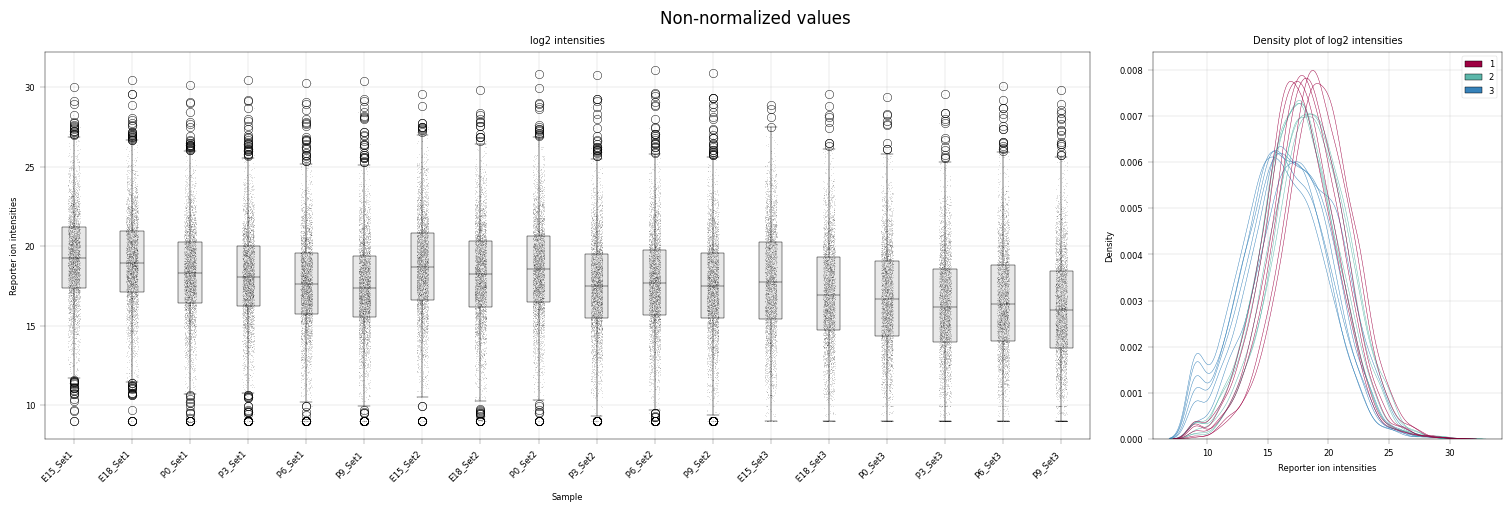

(<Figure size 1500x500 with 2 Axes>,
 <alphapepttools.pl.figure.AxisManager at 0x30dc01dc0>)

In [ ]:
plot_distribution(adata, layer="log2", title="Non-normalized values")

#### 2.2. Total sum normalization (sample loading normalization)

We start with total sum normalization. It assumes that the same total amount of protein was loaded for each sample and rescales every sample so that its total intensity matches a common reference value. Concretely, each feature intensity $f_{i, j}$ of sample $i \in \{1, \dots, N\}$ and feature $j$ is multiplied by a sample-specific factor $s_{i}$:

$$
    \hat{f}_{i, j} = s_{i} \cdot f_{i, j}
$$

with

$$
    s_{i} = \frac{\frac{1}{N}\sum_{i}{\sum_{j}{f_{i, j}}}}{\sum_{j}{f_{i, j}}}
$$

i.e. $s_i$ is the ratio of the grand mean of sample totals to the total of sample $i$.

The assumption of equal total protein amount is only justified _within_ a plex, where the samples were combined in a controlled way. We therefore apply this normalization group-wise by passing the `group_column` argument to `alphapepttools.pp.normalize`.

**Note that the normalization is performed in linear space**, i.e. the data is **not** log-transformed.

In [ ]:
# Normalize the data using the total mean normalization strategy implemented in alphapepttools
adata.layers["normalized__tss"] = adata.layers["raw"].copy()

apt.pp.normalize(adata, layer="normalized__tss", strategy="total_mean", group_column="plex")

# log2 transform the normalized data for better visualization
adata.layers["log2_normalized__tss"] = adata.layers["normalized__tss"].copy()
apt.pp.nanlog(adata, base=2, layer="log2_normalized__tss")

  groups = adata.obs.groupby(group_column, dropna=True).indices



We can now inspect how this affected the sample intensity distributions. The variability within each plex is slightly reduced (note how the red, green and blue curves in the right plot are more closely overlayed), but the distributions still differ substantially _between_ plexes. 

,sample,plex,timepoint,development_stage,day_post_birth,variable,value
0,Reporter ion intensities E15_Set1,1,E15,embryonic,NaN,Cryaa,29.545720
1,Reporter ion intensities E18_Set1,1,E18,embryonic,NaN,Cryaa,30.049073
2,Reporter ion intensities P0_Set1,1,P0,postnatal,0.0,Cryaa,30.322029
3,Reporter ion intensities P3_Set1,1,P3,postnatal,3.0,Cryaa,30.611111
4,Reporter ion intensities P6_Set1,1,P6,postnatal,6.0,Cryaa,30.668285


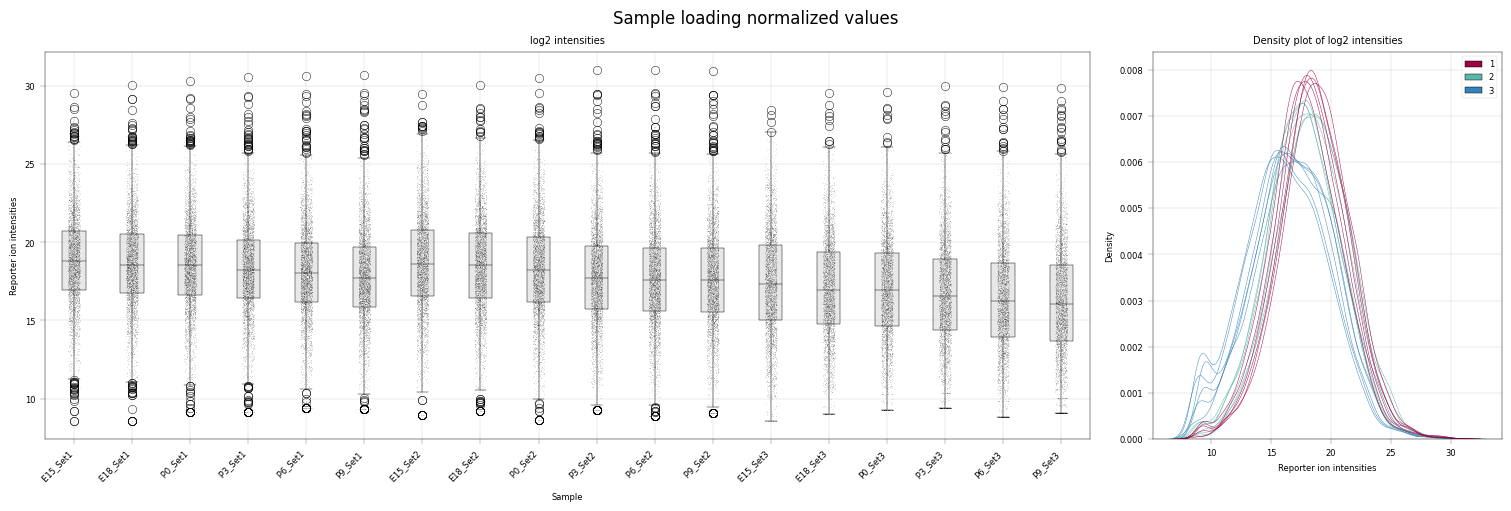

(<Figure size 1500x500 with 2 Axes>,
 <alphapepttools.pl.figure.AxisManager at 0x30dc31640>)

In [ ]:
plot_distribution(adata, layer="log2_normalized__tss", title="Sample loading normalized values")

#### 2.3. Internal reference standard (IRS) normalization

Next, we apply internal reference standard normalization to align intensities _between_ plexes. The assumption is that a sample present in every plex should yield the same measurement each time. For each feature, IRS rescales the per-plex intensities so that the reference samples of all plexes agree with their geometric mean across plexes.

In this dataset we do not have a dedicated reference standard. However, since the same set of conditions is run in every plex, we can construct a virtual reference from the _mean_ of each plex's measurements.

**IRS normalization is also performed in linear space**, i.e. the data is **not** log-transformed.

In [ ]:
# Add a new layer and apply IRS normalization using the sample loading normalized values as input
adata.layers["normalized__irs"] = adata.layers["normalized__tss"].copy()

# Note that when we set reference_column and reference_value to None, the normalization is performed on the per-run arithmetic mean across all samples
apt.pp.irs(adata, group_column="plex", layer="normalized__irs", reference_column=None, reference_value=None)

# log2 transform the IRS normalized data for better visualization
adata.layers["log2_normalized__irs"] = adata.layers["normalized__irs"].copy()
apt.pp.nanlog(adata, base=2, layer="log2_normalized__irs")

  groups = adata.obs.groupby(group_column, dropna=True)



The intensity distributions are now much better aligned across samples and across plexes.

,sample,plex,timepoint,development_stage,day_post_birth,variable,value
0,Reporter ion intensities E15_Set1,1,E15,embryonic,NaN,Cryaa,29.392378
1,Reporter ion intensities E18_Set1,1,E18,embryonic,NaN,Cryaa,29.895731
2,Reporter ion intensities P0_Set1,1,P0,postnatal,0.0,Cryaa,30.168688
3,Reporter ion intensities P3_Set1,1,P3,postnatal,3.0,Cryaa,30.457770
4,Reporter ion intensities P6_Set1,1,P6,postnatal,6.0,Cryaa,30.514943


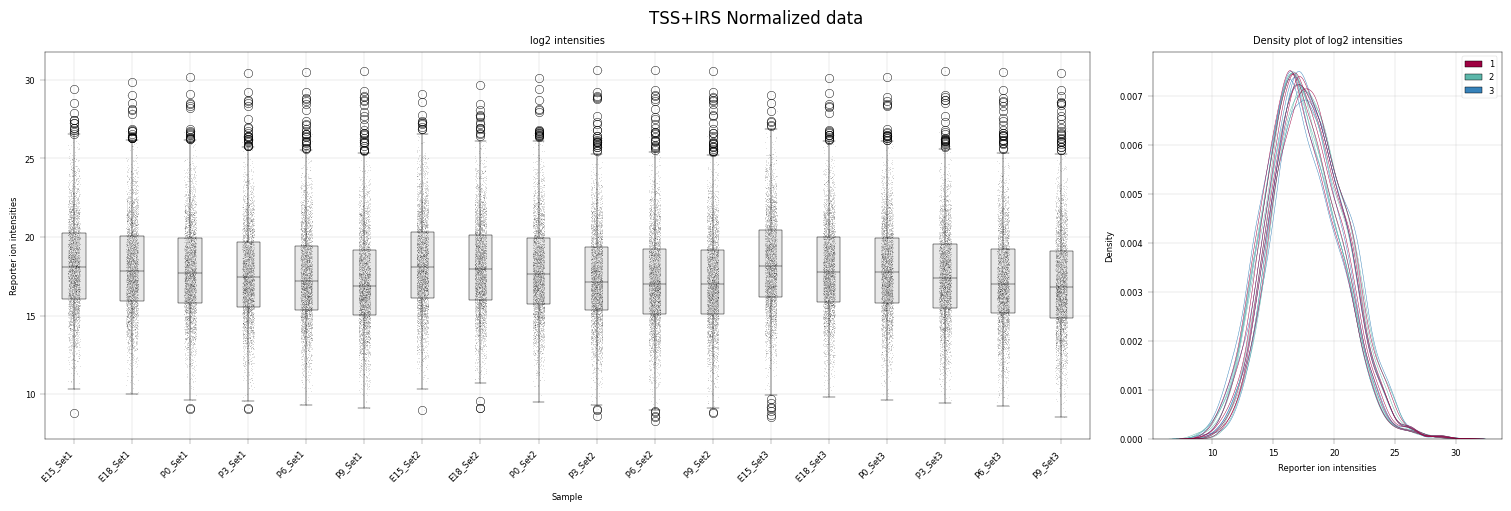

(<Figure size 1500x500 with 2 Axes>,
 <alphapepttools.pl.figure.AxisManager at 0x30eacd790>)

In [ ]:
plot_distribution(adata, layer="log2_normalized__irs", title="TSS+IRS Normalized data")

#### 2.4. ComBat batch correction

As an alternative to IRS normalization, we can run ComBat batch correction. Here we treat the _plexes_ as batches and model their batch effects as a scaling and shifting of the data.

**Note that ComBat assumes approximately normally distributed data**, so the data **should be** log-transformed beforehand.

In [ ]:
adata.layers["log2_combat"] = adata.layers["normalized__tss"].copy()

# Log2 transformation, as ComBat expects approximately normally distributed data.
apt.pp.nanlog(adata, base=2, layer="log2_combat")

apt.pp.scanpy_pycombat(adata, batch="plex", covariates=None, layer="log2_combat")

INFO:alphapepttools.pp.batch_correction: scanpy_pycombat: pply pyComBat to correct for plex
  (abs(g_new - g_old) / g_old).max(), (abs(d_new - d_old) / d_old).max()

  (abs(g_new - g_old) / g_old).max(), (abs(d_new - d_old) / d_old).max()



ComBat also aligns the sample intensity distributions across plexes.

,sample,plex,timepoint,development_stage,day_post_birth,variable,value
0,Reporter ion intensities E15_Set1,1,E15,embryonic,NaN,Cryaa,29.823106
1,Reporter ion intensities E18_Set1,1,E18,embryonic,NaN,Cryaa,30.256894
2,Reporter ion intensities P0_Set1,1,P0,postnatal,0.0,Cryaa,29.959735
3,Reporter ion intensities P3_Set1,1,P3,postnatal,3.0,Cryaa,30.255215
4,Reporter ion intensities P6_Set1,1,P6,postnatal,6.0,Cryaa,30.084903


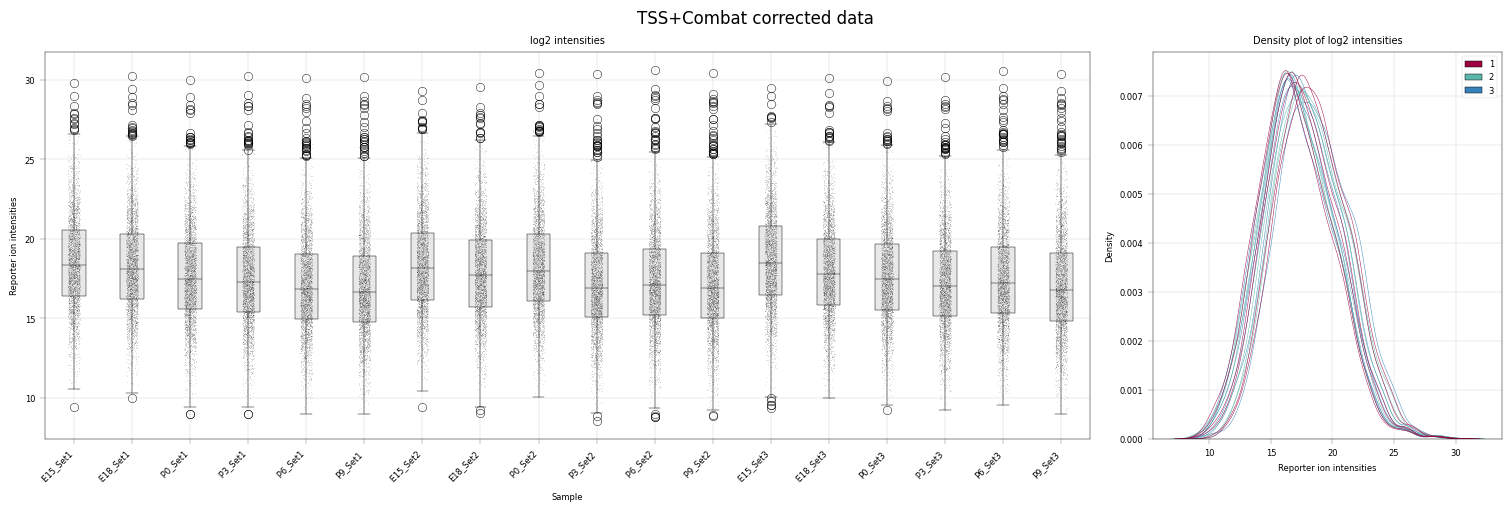

(<Figure size 1500x500 with 2 Axes>,
 <alphapepttools.pl.figure.AxisManager at 0x316f63ce0>)

In [ ]:
plot_distribution(adata, layer="log2_combat", title="TSS+Combat corrected data")

### 3. Qualitative assessment of normalization strategies

As an orthogonal check of normalization quality, we examine the principal components of the data. For a good normalization strategy, we expect samples to order along the developmental axis (biological signal) rather than to cluster by plex (batch effect).

In [ ]:
# Specify groups of layers where we want to evaluate clustering
LAYERS = ("log2", "log2_normalized__tss", "log2_normalized__irs", "log2_combat")

# evaluate PCA embeddings for all layers. We can compute regular PCA components here since we filtered for 100 % data completeness earlier and therefore have no missing values
for layer in LAYERS:
    apt.tl.pca(adata, layer=layer, embeddings_name=f"X_pca__{layer}")

INFO:alphapepttools.tl.embeddings:computing PCA
INFO:alphapepttools.tl.embeddings:computing PCA
INFO:alphapepttools.tl.embeddings:computing PCA
INFO:alphapepttools.tl.embeddings:computing PCA


For each normalization approach, we plot the batch (plex) and biological covariate (timepoint) with `alphapepttools.pl.plot_pca`

  return dispatch(args[0].__class__)(*args, **kw)

  return dispatch(args[0].__class__)(*args, **kw)

  return dispatch(args[0].__class__)(*args, **kw)

  return dispatch(args[0].__class__)(*args, **kw)

  return dispatch(args[0].__class__)(*args, **kw)

  return dispatch(args[0].__class__)(*args, **kw)

  return dispatch(args[0].__class__)(*args, **kw)

  return dispatch(args[0].__class__)(*args, **kw)



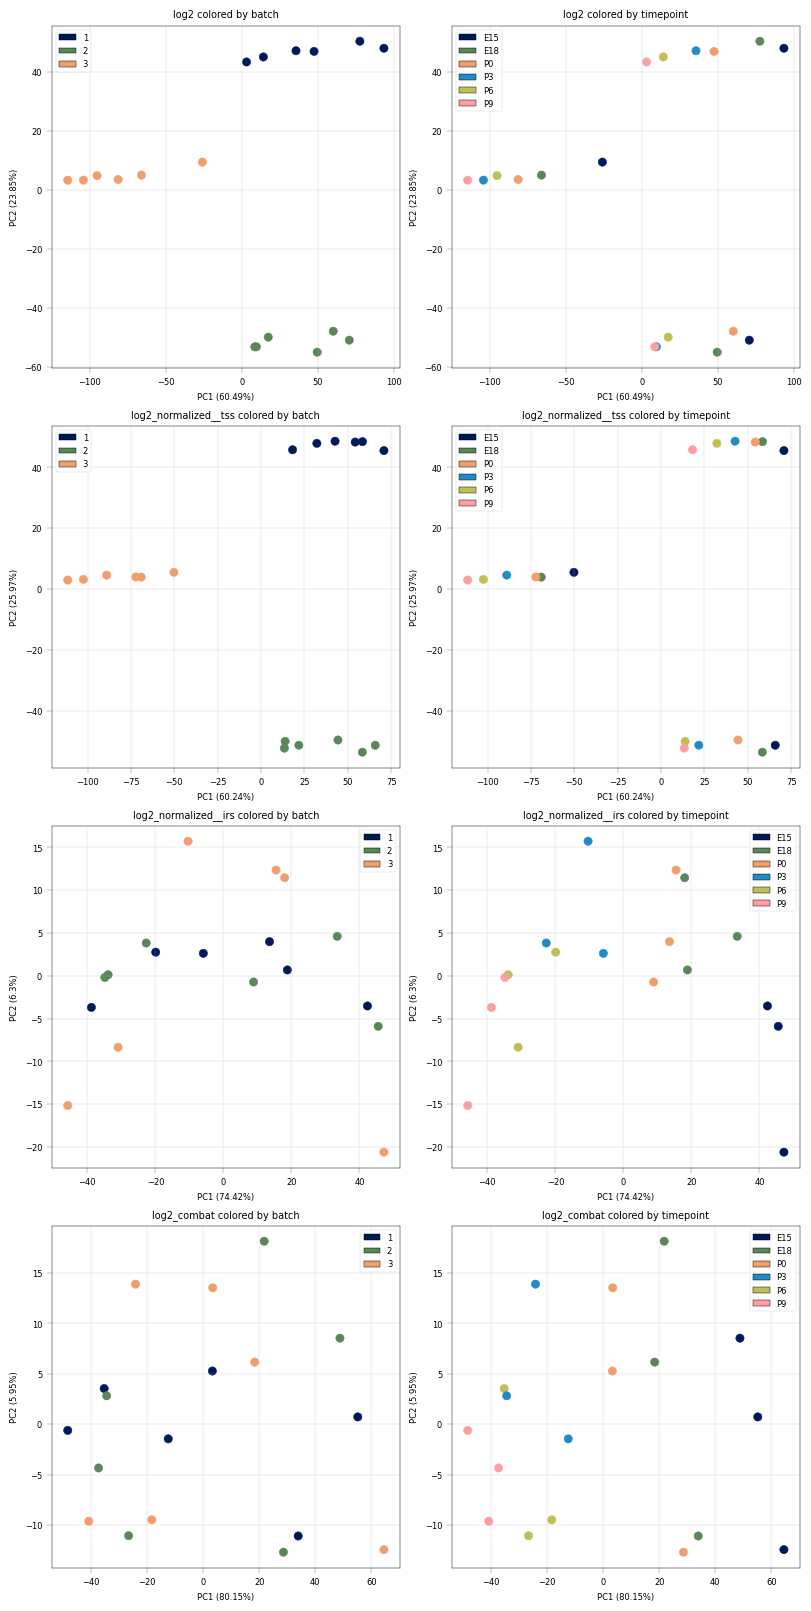

In [ ]:
# Horizontal layout based on layers
fig, axm = apt.pl.create_figure(len(LAYERS), 2, figsize=(8, 4 * len(LAYERS)))

for idx, layer in enumerate(LAYERS):
    # axm is an apt.pl.AxisManager instance, we can either iterate via .next() or directly access a specific subplot
    ax = axm[idx, 0]

    # pca components colored by plex
    apt.pl.plot_pca(ax=ax, data=adata, embeddings_name=f"X_pca__{layer}", color_map_column="plex", legend="auto")

    # ensure consistent fonts and layout
    apt.pl.label_axes(ax=ax, title=f"{layer} colored by batch")

    # next subplot, plot the same PCA embedding but colored by timepoint instead of batch to evaluate whether biological signal is preserved
    ax = axm[idx, 1]

    # pca components colored by timepoint
    apt.pl.plot_pca(ax=ax, data=adata, embeddings_name=f"X_pca__{layer}", color_map_column="timepoint", legend="auto")

    apt.pl.label_axes(ax=ax, title=f"{layer} colored by timepoint")

The raw data (`log2`) and the total sum normalized data (`log2_normalized__tss`) still show a clear batch effect. This matches our expectations: there is between-run variability, and TSS only corrects for within-run differences.

In contrast, both IRS and ComBat mix the batches well, indicating that they successfully account for between-run variability. At the same time, the samples cluster by biological condition (timepoint).

### 4. Quantitative assessment of normalization strategies

#### 4.1. Feature-level metrics

We can also quantify the effect of each normalization procedure with the `alphapepttools.metrics` module. A successful normalization should reduce the variation of feature intensities within biologically homogeneous groups (here, replicates of the same timepoint). We measure this variation with the _pooled median absolute deviation_ (Arend et al, 2025) in log space and with the _pooled coefficient of variation_ in linear space.

First, let's compute the respective metrics:

In [ ]:
LINEAR_LAYERS = ("raw", "normalized__tss", "normalized__irs")

# pooled median absolute deviation
pmad_results = {}
for layer in LAYERS:
    pmad_results[layer] = apt.metrics.pooled_median_absolute_deviation(adata, group_column="timepoint", layer=layer)

# pooled coefficient of variation
cv_results = {}
for layer in LINEAR_LAYERS:
    cv_results[layer] = apt.metrics.pooled_coefficient_of_variation(adata, group_column="timepoint", layer=layer)

# concatenate results into dataframes for better visualization
pmad_results = pd.concat(pmad_results, axis=1).droplevel(level=1, axis=1)
cv_results = pd.concat(cv_results, axis=1).droplevel(level=1, axis=1)

Then plot them.

In [ ]:
pmad_results

,log2,log2_normalized__tss,log2_normalized__irs,log2_combat
E15,0.620715,0.623600,0.139240,0.160353
E18,0.725557,0.680607,0.134424,0.187183
P0,0.697974,0.625522,0.105067,0.168511
P3,0.685566,0.650027,0.145131,0.153706
P6,0.594083,0.650124,0.127830,0.141955
P9,0.641081,0.665097,0.137900,0.115185


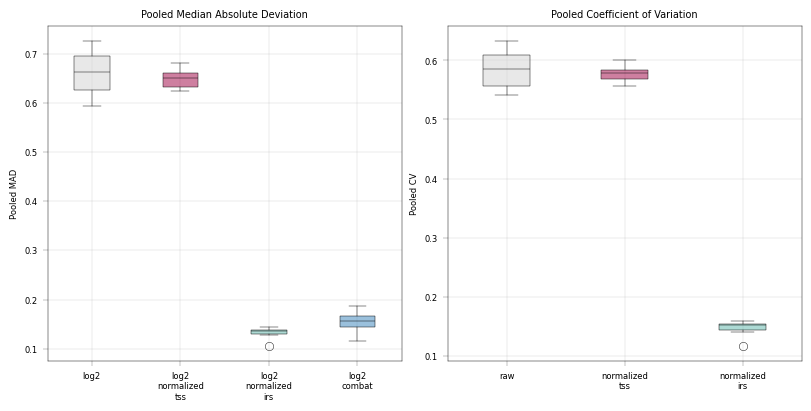

In [ ]:
fig, axm = apt.pl.create_figure(1, 2, figsize=(8, 4))

# consistent coloring
color_dict = {
    "raw": apt.pl.BaseColors.get("grey"),
    "log2": apt.pl.BaseColors.get("grey"),
    "normalized__tss": apt.pl.BaseColors.get("red"),
    "log2_normalized__tss": apt.pl.BaseColors.get("red"),
    "normalized__irs": apt.pl.BaseColors.get("green"),
    "log2_normalized__irs": apt.pl.BaseColors.get("green"),
    "log2_combat": apt.pl.BaseColors.get("blue"),
}

# Boxplot on pmad results
ax = axm.next()
apt.pl.boxplot(
    ax=ax,
    data=pmad_results,
    direct_columns=pmad_results.columns,
    color_dict=color_dict,
)

apt.pl.label_axes(
    ax=ax,
    ylabel="Pooled MAD",
    title="Pooled Median Absolute Deviation",
)

# replace _ and __ in x ticks with newlines
ax.set_xticklabels([s.get_text().replace("__", "\n").replace("_", "\n") for s in ax.get_xticklabels()])

# Boxplot of cv results
ax = axm.next()
apt.pl.boxplot(
    ax=ax,
    data=cv_results,
    direct_columns=cv_results.columns,
    color_dict=color_dict,
)

apt.pl.label_axes(
    ax=ax,
    ylabel="Pooled CV",
    title="Pooled Coefficient of Variation",
)

# replace _ and __ in x ticks with newlines
ax.set_xticklabels([s.get_text().replace("__", "\n").replace("_", "\n") for s in ax.get_xticklabels()])

plt.show()

Both IRS and ComBat markedly reduce the feature variability within biological replicates compared to the unnormalized data, confirming that the normalization worked well.

#### 4.2. Silhouette score

Finally, we compute the average silhouette width (Luecken et al, 2022) for both the batch labels and the biological condition. The silhouette width measures how well-separated the groups of a given label are. For a good normalization strategy we expect batches to be well mixed (low silhouette width for `plex`) while biological conditions remain well separated (high silhouette width for `timepoint`).

In [ ]:
# SKLEARN silhouette score, emulate scib-metrics to avoid extra dependency for this tutorial
from sklearn.metrics import silhouette_score

silhouette_scores = {}
for layer in LAYERS:
    pca_embedding = adata.obsm[f"X_pca__{layer}"]
    silhouette_scores[layer] = {
        "batch": (silhouette_score(pca_embedding, adata.obs["plex"]) + 1) / 2,
        "bio": (silhouette_score(pca_embedding, adata.obs["timepoint"]) + 1) / 2,
    }

silhouette_scores = pd.DataFrame.from_dict(silhouette_scores, orient="index")
silhouette_scores["data"] = silhouette_scores.index

(0.0, 1.0)

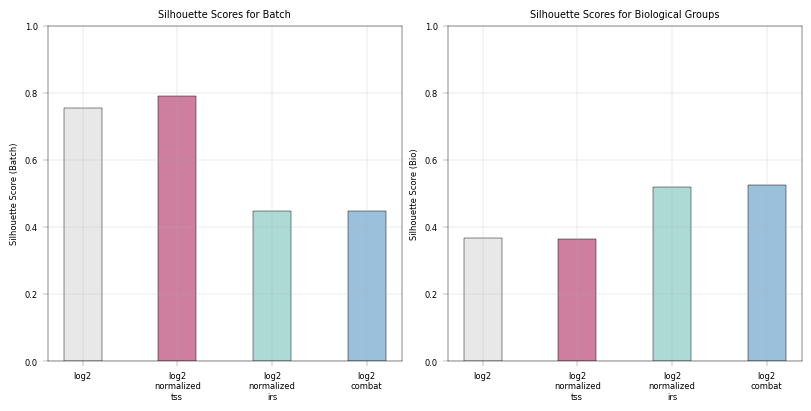

In [ ]:
fig, axm = apt.pl.create_figure(1, 2, figsize=(8, 4))

# Silhouette scores for batch
ax = axm.next()
apt.pl.barplot(
    ax=ax,
    data=silhouette_scores,
    grouping_column="data",
    value_column="batch",
    color_dict=color_dict,
)

# replace _ and __ in x ticks with newlines
ax.set_xticklabels([s.get_text().replace("__", "\n").replace("_", "\n") for s in ax.get_xticklabels()])
apt.pl.label_axes(
    ax=ax,
    ylabel="Silhouette Score (Batch)",
    title="Silhouette Scores for Batch",
)
ax.set_ylim(0, 1)

# Silhouette scores for biological groups
ax = axm.next()
apt.pl.barplot(
    ax=ax,
    data=silhouette_scores,
    grouping_column="data",
    value_column="bio",
    color_dict=color_dict,
)

# replace _ and __ in x ticks with newlines
ax.set_xticklabels([s.get_text().replace("__", "\n").replace("_", "\n") for s in ax.get_xticklabels()])
apt.pl.label_axes(
    ax=ax,
    ylabel="Silhouette Score (Bio)",
    title="Silhouette Scores for Biological Groups",
)
ax.set_ylim(0, 1)

Again, IRS normalization and ComBat batch correction markedly improve both the separation of biological conditions and the mixing of batches.

## Conclusion

In this tutorial we showed that alphapepttools supports the processing of TMT data and explored several strategies for normalizing it. We further demonstrated how alphapepttools can quantify and assess batch effects and judge the success of a normalization strategy.